### Business Background 
 Podha, faces challenges in optimizing its marketing budget, understanding
customer behavior, and improving financial performance. To drive growth
in the competitive plant market, Podha needs data-driven insights. Despite
having data from marketing campaigns, sales transactions, and customer
interactions, the company lacks the analytical depth to leverage this
information effectively.

In [4]:
#importing necessary libraries for the project
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv('Order_Data_meriskill.csv', low_memory=False)
df_copy = df.copy()
df

,OrderID,Region,Country,CustID,Customer_Name,ProductSKU,Product_Category,OrderLineItem,OrderQuantity,ProductCost,ProductPrice,OrderDate,AcquisitionSource,TransactionID,Fraud,PaymentMethod,CardType,Gender
0,SO45080,Northwest,United States,14657,JOHN THOMAS,BK-R50B-58,Plants,1,1.0,413.1463,699.0982,01-01-2020,Meta-ads\r,I4127227587819694,False,CREDITCARD,DISCOVER,M
1,SO45079,Southwest,United States,29255,KYLE WASHINGTON,BK-R93R-48,Plants,1,1.0,2171.2942,3578.27,01-01-2020,Google-ads\r,E9525730529761877,False,CREDITCARD,MC,M
2,SO45082,Australia,Australia,11455,ROSS SANZ,BK-M82B-44,Plants,1,1.0,1898.0944,3374.99,01-01-2020,Google-ads\r,Z6376643485803420,False,CREDITCARD,VISA,M
3,SO45081,Canada,Canada,26782,SETH LEWIS,BK-R50B-44,Plants,1,1.0,413.1463,699.0982,01-01-2020,Google-ads\r,R8609290025411138,False,CREDITCARD,VISA,M
4,SO45083,United Kingdom,United Kingdom,14947,ALEJANDRO CHEN,BK-R93R-48,Plants,1,1.0,2171.2942,3578.27,02-01-2020,Meta-ads\r,Y9572700698484288,False,CREDITCARD,VISA,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55905,SO74143,United Kingdom,United Kingdom,28517,TROY GONZALEZ,WB-H098,Plant Care & Seeds,3,2.0,1.8663,4.99,30-06-2022,Google-ads\r,Q7863980991839908,False,CREDITCARD,MC,M
55906,SO74143,United Kingdom,United Kingdom,28517,TROY GONZALEZ,BC-R205,Plant Care & Seeds,2,1.0,3.3623,8.99,30-06-2022,Google-ads\r,T1770174949094173,False,CREDITCARD,VISA,M
55907,SO74143,United Kingdom,United Kingdom,28517,TROY GONZALEZ,BK-R19B-52,Plants,1,1.0,343.6496,539.99,30-06-2022,Yt-Campaign\r,Z1498721782917223,False,CREDITCARD,AMEX,M
55908,SO74124,France,France,21676,VALERIE GUO,PK-7098,Plant Care & Seeds,2,2.0,0.8565,2.29,30-06-2022,Google-ads\r,J9171882375174307,False,CREDITCARD,MC,M


In [6]:
#retrieving data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55910 entries, 0 to 55909
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrderID            55910 non-null  object 
 1   Region             55910 non-null  object 
 2   Country            55910 non-null  object 
 3   CustID             55910 non-null  object 
 4   Customer_Name      55907 non-null  object 
 5   ProductSKU         55910 non-null  object 
 6   Product_Category   55910 non-null  object 
 7   OrderLineItem      55910 non-null  int64  
 8   OrderQuantity      55910 non-null  float64
 9   ProductCost        55910 non-null  float64
 10  ProductPrice       55910 non-null  object 
 11  OrderDate          55910 non-null  object 
 12  AcquisitionSource  55909 non-null  object 
 13  TransactionID      55910 non-null  object 
 14  Fraud              55207 non-null  object 
 15  PaymentMethod      55910 non-null  object 
 16  CardType           506

In [7]:
df.shape  
#(rows, columns)

(55910, 18)

In [8]:
#checking null values in data
df.isnull().sum()

OrderID                 0
Region                  0
Country                 0
CustID                  0
Customer_Name           3
ProductSKU              0
Product_Category        0
OrderLineItem           0
OrderQuantity           0
ProductCost             0
ProductPrice            0
OrderDate               0
AcquisitionSource       1
TransactionID           0
Fraud                 703
PaymentMethod           0
CardType             5223
Gender               6328
dtype: int64

### Data Cleaning 
      **Key Points**
  
    Identifying and removing duplicates 
    Standardizing data formats 
    Checking for missing values and outliers

In [11]:
#Adjsuting text structure in various columns where needed
df['Customer_Name'] = df['Customer_Name'].str.title()
df['PaymentMethod'] = df['PaymentMethod'].str.title()
df['CardType'] = df['CardType'].str.replace('MC','MASTERCARD')

In [17]:
#Drops null rows for Customer Name and Acquisition Source because its few 
df.dropna(subset=['Customer_Name','AcquisitionSource'], inplace=True)

In [20]:
df.set_index('CustID', inplace=True)

In [22]:
df_dd = df.drop_duplicates(keep='first',inplace=True)
df_dd

In [26]:
df['Gender'].unique()

array(['M', nan, 'X', 'P', 'N', 'U', 'Y', 'S'], dtype=object)

In [28]:
#percentage of rows with null values 
df.isnull().sum().sum() / len(df) * 100

21.915357922226594

In [30]:
#replacing null values in CardType column with Unknown
df['CardType'] = df['CardType'].fillna('Unknown')

In [32]:
#forward filling the fraud null values
df['Fraud'] = df['Fraud'].ffill()

/var/folders/wf/26kn1hg12ls5c_zjv4d23td00000gn/T/ipykernel_24843/2371403690.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Fraud'] = df['Fraud'].ffill()


In [35]:
#checking the number of null values i have left
df.isnull().sum()

OrderID                 0
Region                  0
Country                 0
Customer_Name           0
ProductSKU              0
Product_Category        0
OrderLineItem           0
OrderQuantity           0
ProductCost             0
ProductPrice            0
OrderDate               0
AcquisitionSource       0
TransactionID           0
Fraud                   0
PaymentMethod           0
CardType                0
Gender               6328
dtype: int64

In [37]:
df['AcquisitionSource'].unique()

array(['Meta-ads\r', 'Google-ads\r', 'Yt-Campaign\r'], dtype=object)

In [39]:
#refining the campaign names
source_mapping = {
    'Meta-ads\r': 'Meta',
    'Google-ads\r': 'Google',
    'Yt-Campaign\r': 'YouTube'
}

df['AcquisitionSource'] = df['AcquisitionSource'].map(source_mapping).fillna('Other')

In [41]:
df.tail()

,OrderID,Region,Country,Customer_Name,ProductSKU,Product_Category,OrderLineItem,OrderQuantity,ProductCost,ProductPrice,OrderDate,AcquisitionSource,TransactionID,Fraud,PaymentMethod,CardType,Gender
CustID,,,,,,,,,,,,,,,,,
28517,SO74143,United Kingdom,United Kingdom,Troy Gonzalez,WB-H098,Plant Care & Seeds,3,2.0,1.8663,4.99,30-06-2022,Google,Q7863980991839908,False,Creditcard,MASTERCARD,M
28517,SO74143,United Kingdom,United Kingdom,Troy Gonzalez,BC-R205,Plant Care & Seeds,2,1.0,3.3623,8.99,30-06-2022,Google,T1770174949094173,False,Creditcard,VISA,M
28517,SO74143,United Kingdom,United Kingdom,Troy Gonzalez,BK-R19B-52,Plants,1,1.0,343.6496,539.99,30-06-2022,YouTube,Z1498721782917223,False,Creditcard,AMEX,M
21676,SO74124,France,France,Valerie Guo,PK-7098,Plant Care & Seeds,2,2.0,0.8565,2.29,30-06-2022,Google,J9171882375174307,False,Creditcard,MASTERCARD,M
21676,SO74124,France,France,Valerie Guo,TI-R092,Plant Care & Seeds,1,2.0,8.0373,21.49,30-06-2022,Google,H1731861796382481,False,Paypal,Unknown,NaN


In [43]:
#changing Product Price data type to float for accurate calculation with other float columns
df['ProductPrice'] = df['ProductPrice'].astype(float)

In [45]:
#creating new column to calculate total price and total product cost 
df['TotalProductPrice'] = (df['OrderQuantity'] * df['ProductPrice']).round(2)
df['TotalProductCost'] = (df['OrderQuantity'] * df['ProductCost']).round(2)

In [47]:
df.sample(5)

,OrderID,Region,Country,Customer_Name,ProductSKU,Product_Category,OrderLineItem,OrderQuantity,ProductCost,ProductPrice,OrderDate,AcquisitionSource,TransactionID,Fraud,PaymentMethod,CardType,Gender,TotalProductPrice,TotalProductCost
CustID,,,,,,,,,,,,,,,,,,,
19161,SO57285,Southwest,United States,Jeremiah Hughes,WB-H098,Plant Care & Seeds,4,2.0,1.8663,4.9900,02-11-2021,Google,X2027273361219218,False,Paypal,MASTERCARD,M,9.98,3.73
23132,SO54546,Southwest,United States,Anthony Lee,PK-7098,Plant Care & Seeds,2,1.0,0.8565,2.2900,18-09-2021,Google,Q5301249312846826,False,Creditcard,VISA,NaN,2.29,0.86
13447,SO60364,Southwest,United States,Destiny Cox,FE-6654,Plant Care & Seeds,2,2.0,8.2205,21.9800,19-12-2021,YouTube,H5656663943017982,False,Creditcard,VISA,M,43.96,16.44
19443,SO45879,Germany,Germany,Dominic Raman,BK-R50B-44,Plants,1,1.0,413.1463,699.0982,12-04-2020,Google,W5742767475349627,False,Creditcard,Unknown,M,699.10,413.15
24221,SO72428,Southwest,United States,Heidi Perez,BK-R19B-52,Plants,1,1.0,343.6496,539.9900,07-06-2022,YouTube,X5137449051927395,False,Creditcard,VISA,M,539.99,343.65


In [49]:
#creating new column to calculate profit per customer sale
df['TotalProfit'] = df['TotalProductPrice'] - df['TotalProductCost']

In [51]:
#rounding all float columns to 2 decimals to avoid lots of decimal numbers 
float_cols = df.select_dtypes(include='float').columns
df[float_cols] = df[float_cols].round(2)


### Assessing the financial performance of each marketing campaign by calculating profitability metrics.

In [54]:
#calculating per-user profitability for each campaign.
campaign_summary = df.groupby('AcquisitionSource').agg(
    total_profit=('TotalProfit', 'sum'),
    user_count=('Customer_Name', 'nunique')
).reset_index()


In [56]:
campaign_summary

,AcquisitionSource,total_profit,user_count
0,Google,8326225.41,16587
1,Meta,1079293.26,4728
2,YouTube,1039930.83,4749


In [58]:
campaign_summary['profitability'] = (
    campaign_summary['total_profit'] / campaign_summary['user_count']
)


***For each acquisition source, the total profit the business made,
number of unique customers they got, and on average, the amount of profit each customer brought in?***


In [61]:
campaign_summary

,AcquisitionSource,total_profit,user_count,profitability
0,Google,8326225.41,16587,501.972955
1,Meta,1079293.26,4728,228.276916
2,YouTube,1039930.83,4749,218.978907


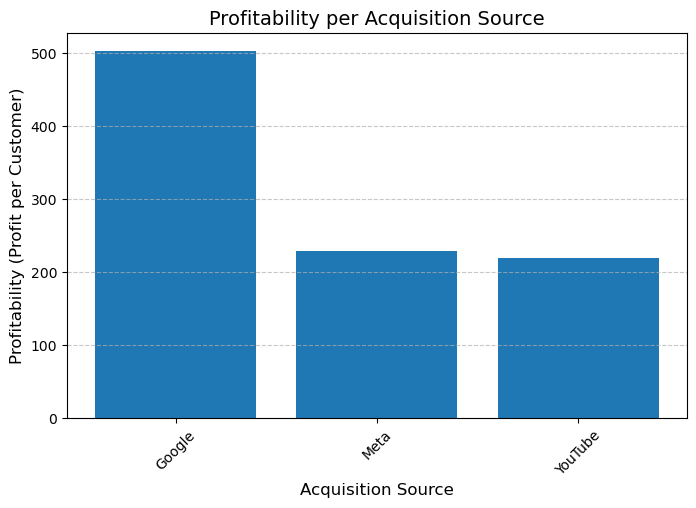

In [64]:
import matplotlib.pyplot as plt
# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(campaign_summary['AcquisitionSource'], campaign_summary['profitability'])

# Add labels and title
plt.title('Profitability per Acquisition Source', fontsize=14)
plt.xlabel('Acquisition Source', fontsize=12)
plt.ylabel('Profitability (Profit per Customer)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


### Comparing the profitability of different campaigns to determine which one was the most effective.

In [67]:
#cs means campaign summary
cs = df.groupby('AcquisitionSource').agg(
    total_profit=('TotalProfit', 'sum'),
    total_cost=('TotalProductCost', 'sum'),
    user_count=('Customer_Name', 'nunique')
).reset_index()

# Profitability metrics
cs['profit_per_user'] = cs['total_profit'] / cs['user_count']
cs['cost_per_user'] = cs['total_cost'] / cs['user_count']


In [69]:
cs

,AcquisitionSource,total_profit,total_cost,user_count,profit_per_user,cost_per_user
0,Google,8326225.41,11509533.98,16587,501.972955,693.888827
1,Meta,1079293.26,1493114.45,4728,228.276916,315.802549
2,YouTube,1039930.83,1438435.17,4749,218.978907,302.892224


In [71]:
# Sort by profit per user (descending)
cs.sort_values('profit_per_user', ascending=False, inplace=True)

# Quick statistical summary
cs.describe()


,total_profit,total_cost,user_count,profit_per_user,cost_per_user
count,3.000000e+00,3.000000e+00,3.000000,3.000000,3.000000
mean,3.481816e+06,4.813695e+06,8688.000000,316.409593,437.527867
std,4.195427e+06,5.798832e+06,6840.742723,160.769818,222.108928
min,1.039931e+06,1.438435e+06,4728.000000,218.978907,302.892224
25%,1.059612e+06,1.465775e+06,4738.500000,223.627912,309.347386
50%,1.079293e+06,1.493114e+06,4749.000000,228.276916,315.802549
75%,4.702759e+06,6.501324e+06,10668.000000,365.124936,504.845688
max,8.326225e+06,1.150953e+07,16587.000000,501.972955,693.888827


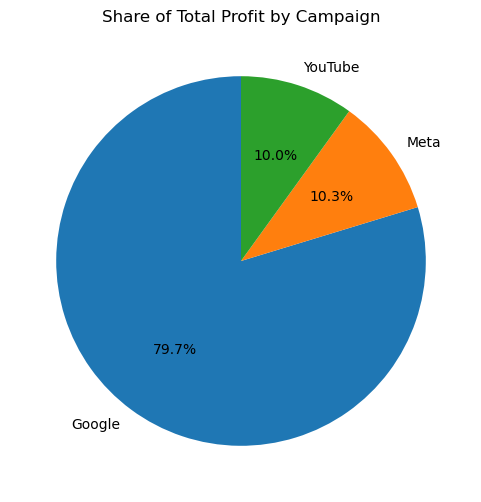

In [222]:
cs.set_index('AcquisitionSource')['total_profit'].plot(
    kind='pie', autopct='%1.1f%%', figsize=(6, 6), startangle=90
)
plt.title('Share of Total Profit by Campaign')
plt.ylabel('')
plt.show()

***Google is the most effective, generating the highest profit per user,
while Youtube had the lowest acquisition cost***

### Analyzing conversion rates and Customer Acquisition Costs (CAC) for each acquisition source to determine the most efficient source for budget allocation.

In [193]:
#convert column to track users who actually made contribution to the company's profit
df['Converted'] = (df['TotalProfit'] > 0).astype(int)

In [195]:
#grouping data by AcquisitionSource to prepare for analysis.
campaign_data = df.groupby('AcquisitionSource').agg(
    total_users=('Customer_Name', 'nunique'),
    total_conversions=('Converted', 'sum'),   # assuming 1 = converted, 0 = not converted
    total_cost=('ProductCost', 'sum')
).reset_index()


In [197]:
df.head()

,OrderID,Region,Country,Customer_Name,ProductSKU,Product_Category,OrderLineItem,OrderQuantity,ProductCost,ProductPrice,...,AcquisitionSource,TransactionID,Fraud,PaymentMethod,CardType,Gender,TotalProductPrice,TotalProductCost,TotalProfit,Converted
CustID,,,,,,,,,,,,,,,,,,,,,
14657,SO45080,Northwest,United States,John Thomas,BK-R50B-58,Plants,1,1.0,413.15,699.10,...,Meta,I4127227587819694,False,Creditcard,DISCOVER,M,699.10,413.15,285.95,1
29255,SO45079,Southwest,United States,Kyle Washington,BK-R93R-48,Plants,1,1.0,2171.29,3578.27,...,Google,E9525730529761877,False,Creditcard,MASTERCARD,M,3578.27,2171.29,1406.98,1
11455,SO45082,Australia,Australia,Ross Sanz,BK-M82B-44,Plants,1,1.0,1898.09,3374.99,...,Google,Z6376643485803420,False,Creditcard,VISA,M,3374.99,1898.09,1476.90,1
26782,SO45081,Canada,Canada,Seth Lewis,BK-R50B-44,Plants,1,1.0,413.15,699.10,...,Google,R8609290025411138,False,Creditcard,VISA,M,699.10,413.15,285.95,1
14947,SO45083,United Kingdom,United Kingdom,Alejandro Chen,BK-R93R-48,Plants,1,1.0,2171.29,3578.27,...,Meta,Y9572700698484288,False,Creditcard,VISA,M,3578.27,2171.29,1406.98,1


In [199]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost
0,Google,16587,44646,11411395.61
1,Meta,4728,5618,1480903.50
2,YouTube,4749,5642,1426128.25


In [201]:
campaign_data['conversion_rate'] = (
    campaign_data['total_conversions'] / campaign_data['total_users']
) * 100


*The conversion rate measures how many users converted (e.g., made a purchase)
out of the total number of users reached or acquired.
Conversion Rate = Number of Conversions / Number of Users × 100*

In [204]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost,conversion_rate
0,Google,16587,44646,11411395.61,269.162597
1,Meta,4728,5618,1480903.50,118.824027
2,YouTube,4749,5642,1426128.25,118.803959


Insight:

Google achieved the highest conversion rate (269.16%), suggesting it is highly effective at converting users.

Meta and YouTube showed similar conversion rates (~118%), performing moderately well but below Google 

In [207]:
campaign_data['CAC'] = campaign_data['total_cost'] / campaign_data['total_conversions']


In [209]:
campaign_data['CAC']

0    255.597268
1    263.599769
2    252.769984
Name: CAC, dtype: float64

In [211]:
campaign_data.sort_values(
    by=['conversion_rate', 'CAC'],
    ascending=[False, True],
    inplace=True
)


In [213]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost,conversion_rate,CAC
0,Google,16587,44646,11411395.61,269.162597,255.597268
1,Meta,4728,5618,1480903.50,118.824027,263.599769
2,YouTube,4749,5642,1426128.25,118.803959,252.769984


Insight:

YouTube had the lowest CAC (₵252.77), meaning it’s the cheapest source to acquire customers.

Meta had the highest CAC (₵263.60), slightly more expensive per customer.

Google’s CAC (₵255.60) is still efficient considering its high conversion performance.

/var/folders/wf/26kn1hg12ls5c_zjv4d23td00000gn/T/ipykernel_24843/3989935460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


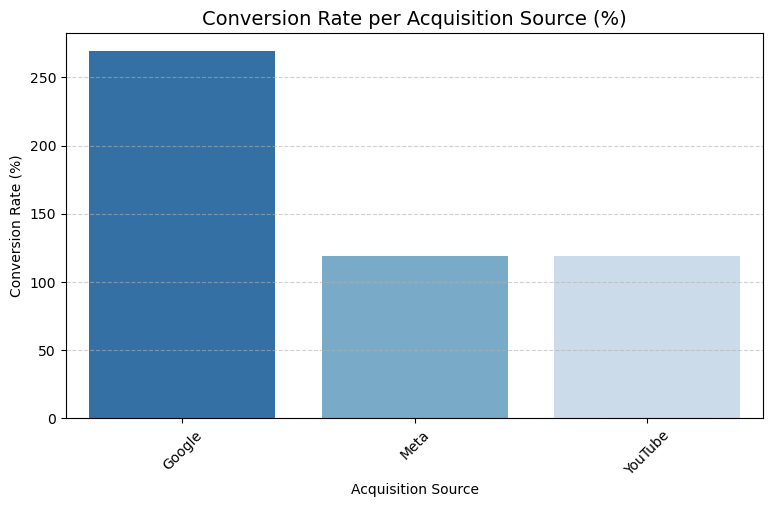

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.barplot(
    data=campaign_data,
    x='AcquisitionSource',
    y='conversion_rate',
    palette='Blues_r'
)
plt.title('Conversion Rate per Acquisition Source (%)', fontsize=14)
plt.xlabel('Acquisition Source')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


/var/folders/wf/26kn1hg12ls5c_zjv4d23td00000gn/T/ipykernel_24843/2456777511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


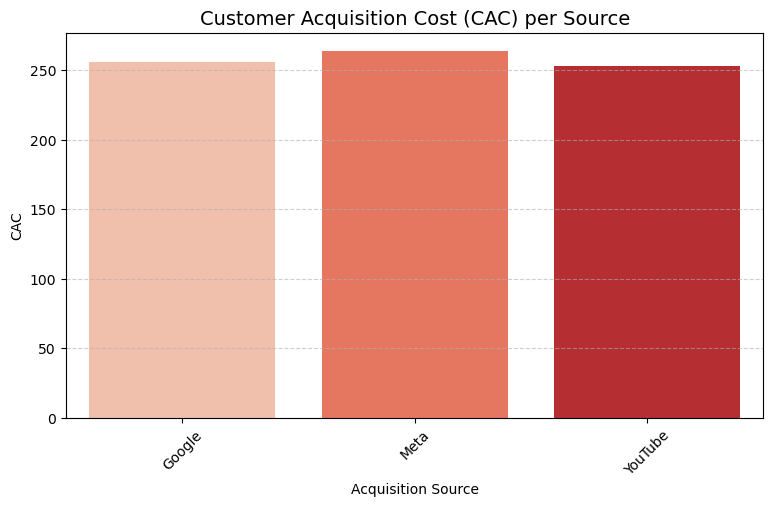

In [157]:
#CAC Comparision
plt.figure(figsize=(9, 5))
sns.barplot(
    data=campaign_data,
    x='AcquisitionSource',
    y='CAC',
    palette='Reds'
)
plt.title('Customer Acquisition Cost (CAC) per Source', fontsize=14)
plt.xlabel('Acquisition Source')
plt.ylabel('CAC')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


**Based on the analysis, Google is the most effective acquisition source overall, achieving the highest conversion rate (269%) while maintaining a reasonable CAC.
YouTube is also efficient in terms of cost, making it a good secondary channel.
Meta, however, shows weaker performance and may not be the optimal platform for high ROI**

### Forecasting customer acquisition numbers based on budget allocation and create visualizations to communicate predictions.

In [164]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost,conversion_rate,CAC,budget,expected_customers
0,Google,16587,44646,11411395.61,269.162597,255.597268,1.711709e+07,66969.0
1,Meta,4728,5618,1480903.50,118.824027,263.599769,2.221355e+06,8427.0
2,YouTube,4749,5642,1426128.25,118.803959,252.769984,2.139192e+06,8463.0


In [218]:
#creating a custom budget for the campaign 
campaign_data['budget'] = campaign_data['total_cost'] * 1.5

In [171]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost,conversion_rate,CAC,budget,expected_customers
0,Google,16587,44646,11411395.61,269.162597,255.597268,1.711709e+07,66969.0
1,Meta,4728,5618,1480903.50,118.824027,263.599769,2.221355e+06,8427.0
2,YouTube,4749,5642,1426128.25,118.803959,252.769984,2.139192e+06,8463.0


In [173]:
campaign_data['expected_customers'] = campaign_data['budget'] / campaign_data['CAC']

In [175]:
campaign_data

,AcquisitionSource,total_users,total_conversions,total_cost,conversion_rate,CAC,budget,expected_customers
0,Google,16587,44646,11411395.61,269.162597,255.597268,1.711709e+07,66969.0
1,Meta,4728,5618,1480903.50,118.824027,263.599769,2.221355e+06,8427.0
2,YouTube,4749,5642,1426128.25,118.803959,252.769984,2.139192e+06,8463.0


**Building a Linear Regression model to forecast future customer counts**

In [178]:
X = campaign_data[['budget']] #independent variable
y = campaign_data['total_users'] #these are the current customers = dependent variable

In [180]:
model = LinearRegression()
model.fit(X,y)


LinearRegression()

In [182]:
new_budgets = np.array([[6000000000], 
                        [700000000],     
                        [800000000]])
predictions = model.predict(new_budgets) 

for b, p in zip(new_budgets.flatten(), predictions):
    print(f"Predicted customers for budget ₵{b:,}: {p:.0f}")

Predicted customers for budget ₵6,000,000,000: 4762313
Predicted customers for budget ₵700,000,000: 558261
Predicted customers for budget ₵800,000,000: 637583


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


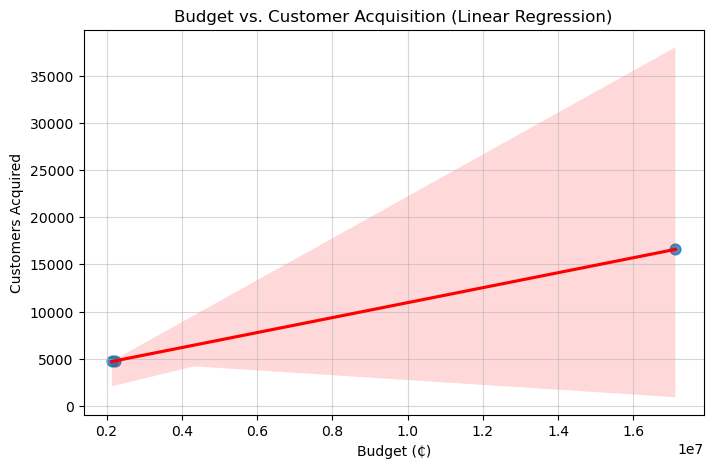

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.regplot(x='budget', y='total_users', data=campaign_data, scatter_kws={'s':60}, line_kws={'color':'red'})
plt.title('Budget vs. Customer Acquisition (Linear Regression)')
plt.xlabel('Budget (₵)')
plt.ylabel('Customers Acquired')
plt.grid(alpha=0.5)
plt.show() 
